In [66]:
import os
import pandas as pd
import zipfile
import glob
from PIL import Image
%matplotlib inline
import matplotlib.pyplot as plt
import math
import numpy as np

In [67]:
# 解压缩

dir_path=r".\data.zip"
extract_path=r".\data"

os.makedirs(extract_path,exist_ok=True)
with zipfile.ZipFile(dir_path,"r") as f:
    f.extractall(extract_path)

print("解压缩完成")

解压缩完成


In [68]:
monet_path=os.path.join(extract_path,"data","monet_jpg")
photo_path=os.path.join(extract_path,"data","photo_jpg")

In [69]:
def display(path,show_num=16):
    _,axes=plt.subplots(math.ceil(math.sqrt(show_num)),math.ceil(math.sqrt(show_num)),figsize=(10,10))
    for i,file in enumerate(glob.glob(path+"\*",recursive=True)):
        if i>15: break
        img=Image.open(file)
        axes.flat[i].imshow(img)
        axes.flat[i].axis("off")
    plt.suptitle(os.path.basename(path)[:5], fontsize=20)  
    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()


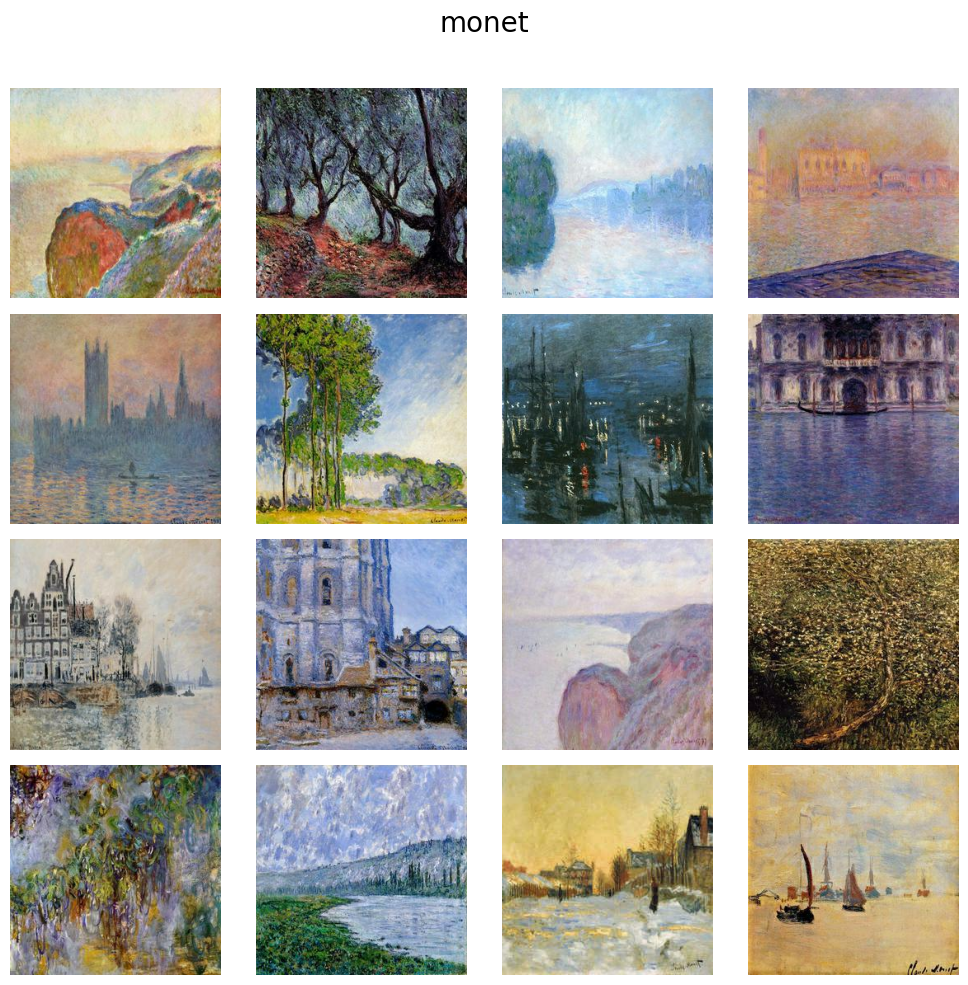

In [70]:
display(monet_path)

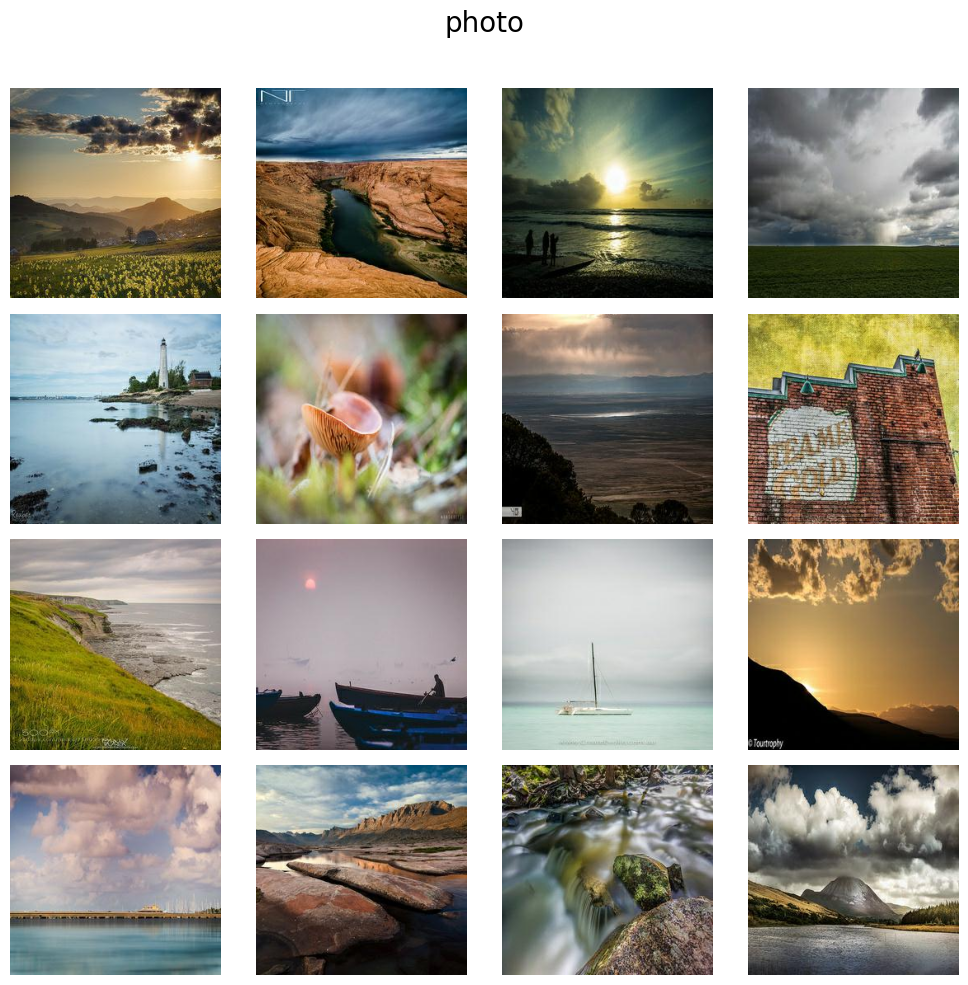

In [71]:
display(photo_path)

<h2><center>基础分析</center></h2>

In [72]:
# 图片大小分析
def image_size(img_path):
    height,width=[],[]
    for file in glob.glob(img_path+"\*",recursive=True):
        img=Image.open(file)
        height.append(img.size[1])
        width.append(img.size[0])
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    plt.hist(width,bins=30,color="b")
    plt.title("width")

    plt.subplot(122)
    plt.hist(height,bins=30,color="r")
    plt.title("height")
    
    plt.suptitle(os.path.basename(img_path)[:5])
    plt.tight_layout()
    plt.show()

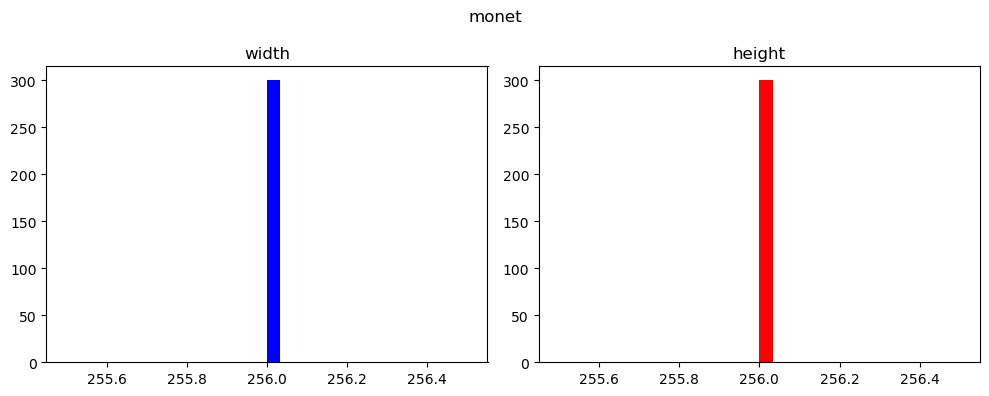

In [73]:
image_size(monet_path)

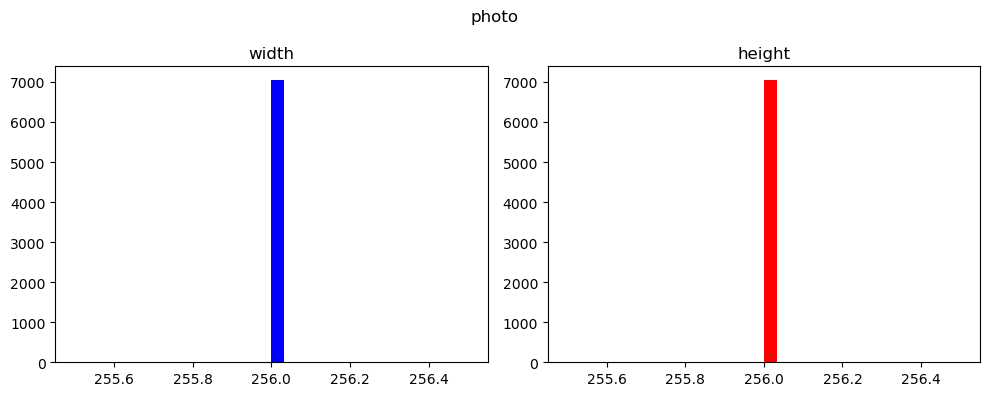

In [74]:
image_size(photo_path)

In [75]:
# 单张图片像素分布分析，可体现像素风格

def image_pixel(img_path,_id=0):
    assert type(_id)==int
    file_path=glob.glob(img_path+"\*",recursive=True)[_id]
    img=Image.open(file_path)
    img=np.array(img)
    plt.figure(figsize=(12,4))
    
    plt.subplot(141)
    plt.imshow(img)
    plt.title(f"image__{os.path.basename(img_path)[:5]}")
    plt.axis("off")
    
    plt.subplot(142)
    plt.hist(img[:,:,0].reshape(-1),bins=30,color="r",density=True)
    plt.title("R")

    plt.subplot(143)
    plt.hist(img[:,:,1].reshape(-1),bins=30,color="g",density=True)
    plt.title("G")

    plt.subplot(144)
    plt.hist(img[:,:,2].reshape(-1),bins=30,color="b",density=True)
    plt.title("B")
    
    plt.tight_layout()
    plt.show()

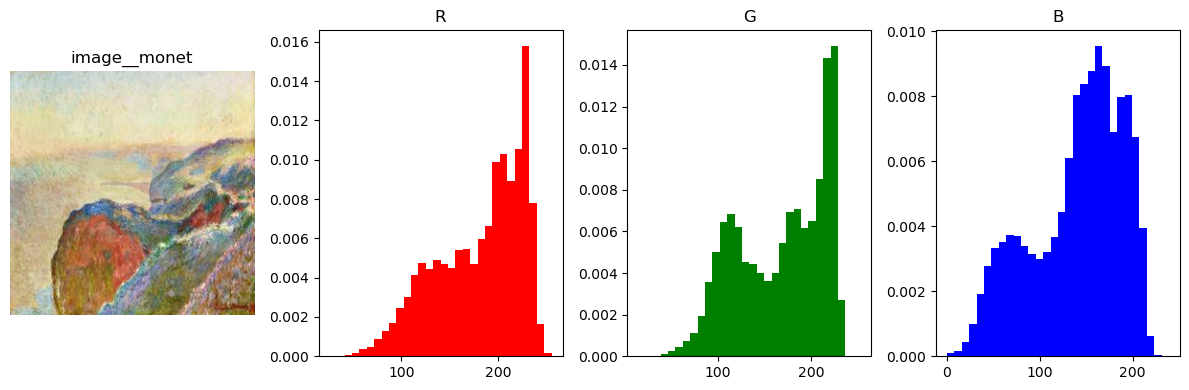

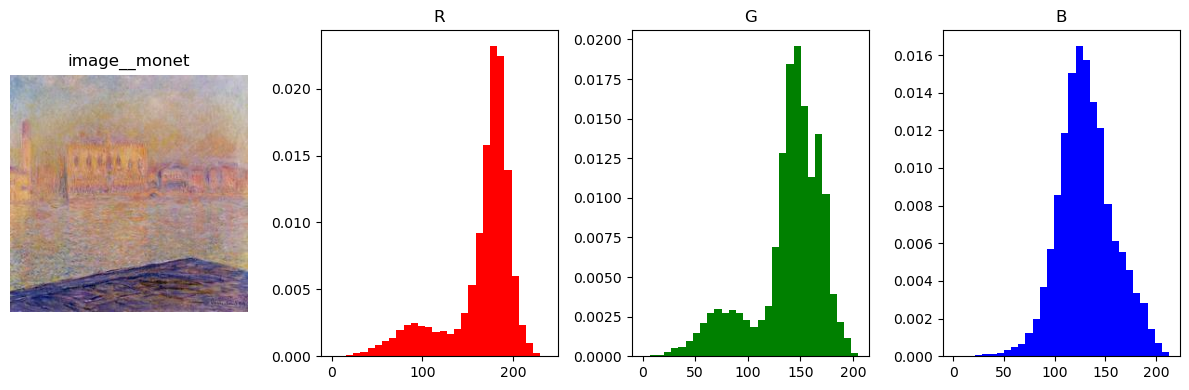

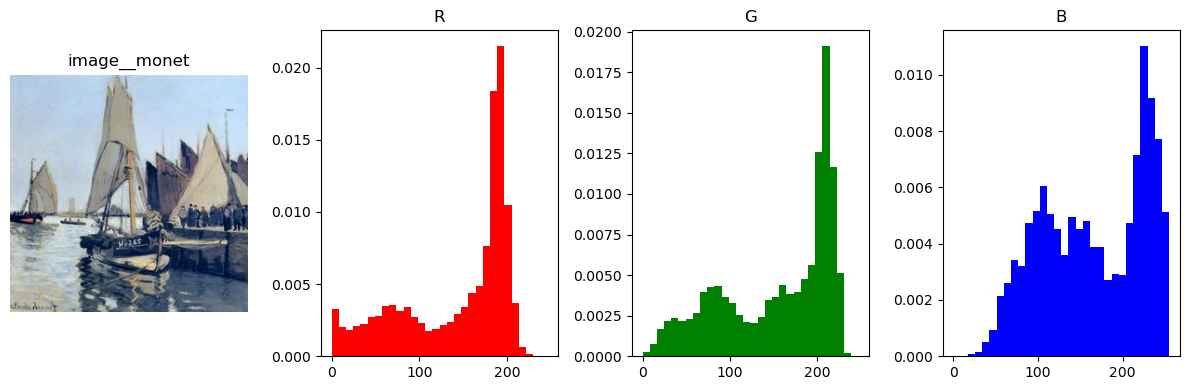

In [76]:
image_pixel(monet_path)
image_pixel(monet_path,3)
image_pixel(monet_path,78)

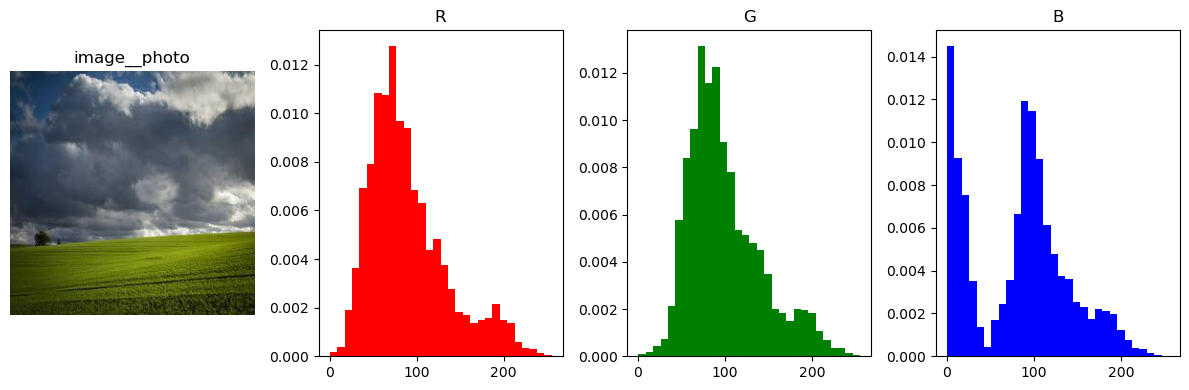

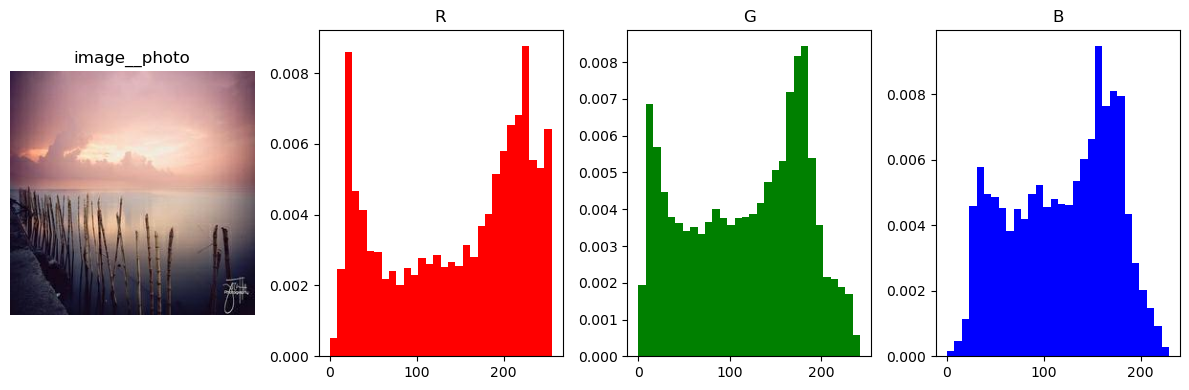

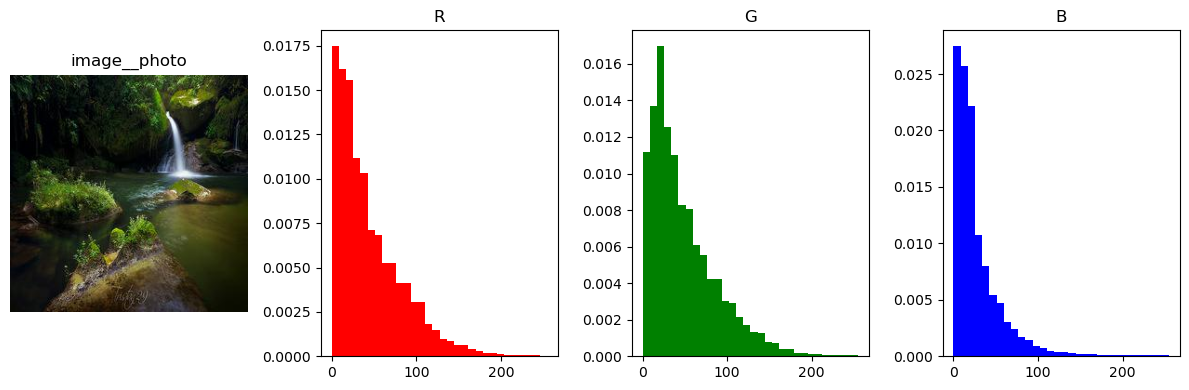

In [77]:
image_pixel(photo_path,45)
image_pixel(photo_path,456)
image_pixel(photo_path,324)

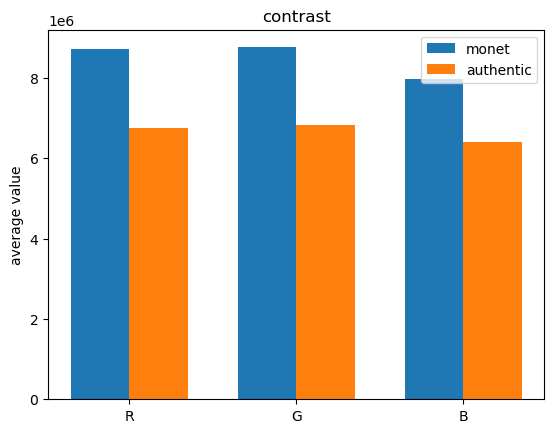

In [78]:
# 探索其画作风格

def channel_sum(img_path):
    record=np.zeros(3)
    total_images=0
    for file in glob.glob(img_path+"\*",recursive=True):
        img=Image.open(file)
        img=np.array(img)
        record+=np.sum(img,axis=(0,1))
        total_images+=1
    return record/total_images

monet_average=channel_sum(monet_path)
photo_average=channel_sum(photo_path)
x=np.arange(3)
channels=["R","G","B"]
width=0.35
plt.bar(x-width/2,monet_average,width=width,label="monet")
plt.bar(x+width/2,photo_average,width=width,label="authentic")
plt.legend()
plt.ylabel("average value")
plt.xticks(x,channels)
plt.title("contrast")
plt.show()

In [96]:
# 数据集搭建
import torch
from torch import nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,Dataset
import random

class MonetDataset(Dataset):
    def __init__(self,monet_path,photo_path,size=(256,256)):
        super().__init__()
        random.seed(None)
        self.monet_path=glob.glob(monet_path+"\*")
        self.photo_path=glob.glob(photo_path+"\*")
        random.shuffle(self.monet_path)
        random.shuffle(self.photo_path)
        self.transforms=transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(size),
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
        ])
        random.seed(42)
    def __len__(self):
        return min(len(self.monet_path),len(self.photo_path))

    def __getitem__(self,idx):
        monet_img=self.transforms(Image.open(self.monet_path[idx]))
        photo_img=self.transforms(Image.open(self.photo_path[idx]))
        return monet_img,photo_img

In [97]:
def reverse_img(img,mean=[0.5]*3,std=[0.5]*3):
    for img_channel,mean_channel,std_channel in zip(img,mean,std):
        img_channel.mul_(std_channel).add_(mean_channel)
    return img

In [155]:
def seed_(seed):
    random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    np.random.seed(42)
    
seed_(configue["seed"])

In [99]:
data_iter=DataLoader(MonetDataset(monet_path,photo_path),
                     batch_size=configue["batch_size"],
                     shuffle=True,
                     pin_memory=True,)

In [117]:
class Upsample_block(nn.Module):
    def __init__(self,in_ch,out_ch,dropout_ratio=0.5):
        super().__init__()
        #  output_size=strideinput_size−kernel_size+2×padding+1
        self.convT=nn.ConvTranspose2d(in_ch,out_ch,3,padding=1,stride=2,output_padding=1)
        self.norm=nn.InstanceNorm2d(out_ch)
        self.dropout=nn.Dropout(dropout_ratio)
        self.activation=nn.GELU()
    def forward(self,X):
        return self.activation(self.dropout(self.norm(self.convT(X))))

class Conv_block(nn.Module):
    def __init__(self,in_ch,out_ch,kernel_size=3,padding=1,stride=2):
        super().__init__()
        self.conv_layer=nn.Conv2d(in_ch,out_ch,kernel_size,stride=stride,padding=padding)
        self.activation=nn.GELU()
        self.norm=nn.InstanceNorm2d(out_ch)
    def forward(self,X):
        return self.activation(self.norm(self.conv_layer(X)))

class Res_Block(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.pad=nn.ReflectionPad2d(1)
        self.conv=nn.Conv2d(ch,ch,kernel_size=3,stride=1,padding=0)
        self.norm=nn.InstanceNorm2d(ch)
        self.activation=nn.GELU()
        self.dropout=nn.Dropout(0.4)
    def forward(self,X):
        X1=self.dropout(self.activation(self.norm(self.conv(self.pad(X)))))
        X2=self.dropout(self.activation(self.norm(self.conv(self.pad(X1)))))
        return X2+X

In [132]:
class Generator(nn.Module):
    def __init__(self,in_ch,out_ch,ResBlock_num=6):
        super().__init__()
        self.model=nn.Sequential(nn.ReflectionPad2d(3),
                           Conv_block(in_ch,64,7,stride=1,padding=0),
                           Conv_block(64,128,3,stride=2,padding=1),
                           Conv_block(128,256,3,stride=2,padding=1),
                            # 抽取特征
                            *[Res_Block(256) for _ in range(ResBlock_num)],
                            # 上采样
                            Upsample_block(256,128),
                            Upsample_block(128,64),
                            #抽取全局特征
                            nn.ReflectionPad2d(3),
                            nn.Conv2d(64,out_ch,7,stride=1,padding=0),
                            nn.Tanh()
                           )
    def forward(self,X):
        return self.model(X)
# PatchGAN

class Discriminator(nn.Module):
    def __init__(self,in_ch,num_layers=3):
        super().__init__()
        model=nn.Sequential(
            nn.Conv2d(in_ch,64,4,stride=2,padding=1),
            nn.GELU(),
        )
        for i in range(1,num_layers+1):
            in_ch=64*(2**(i-1))
            out_ch=in_ch*2
            if i ==num_layers:
                model.append(Conv_block(in_ch,out_ch,4,2))
            else :
                model.append(Conv_block(in_ch,out_ch,4,1))
        model.append(nn.Conv2d(2**(num_layers)*64,1,4,stride=1,padding=1))
        self.model=model
    def forward(self,X):
        return self.model(X)

In [133]:
def init_weight(m):
    class_name=m.__class__.__name__
    if class_name in ["Conv2d","ConvTranspose2d"]:
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    if class_name=="Conv2d" and m.out_channels==3:
        nn.init.normal_(m.weight,std=0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [134]:
class sample_fake(object):
    def __init__(self, max_imgs=50):
        self.max_imgs = max_imgs
        self.cur_img = 0
        self.imgs = list()

    def __call__(self, imgs):
        ret = list()
        np.random.seed(None)
        for img in imgs:
            if self.cur_img < self.max_imgs:
                self.imgs.append(img)
                ret.append(img)
                self.cur_img += 1
            else:
                if np.random.ranf() > 0.5:
                    idx = np.random.randint(0, self.max_imgs)
                    ret.append(self.imgs[idx])
                    self.imgs[idx] = img
                else:
                    ret.append(img)
        np.random.seed(configue["seed"])
        return ret

In [135]:
class lr_sched():
    def __init__(self, decay_epochs=100, total_epochs=200):
        self.decay_epochs = decay_epochs
        self.total_epochs = total_epochs

    def step(self, epoch_num):
        if epoch_num <= self.decay_epochs:
            return 1.0
        else:
            fract = (epoch_num - self.decay_epochs)  / (self.total_epochs - self.decay_epochs)
            return 1.0 - fract

In [136]:
class Accumulator:
    def __init__(self,num):
        self.metric=[0]*num
    def __getitem__(self,idx):
        return self.metric[idx]
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i]+=arg

class Recorder:
    def __init__(self,num):
        self.metric=[[] for _ in range(num)]
    def __getitem__(self,idx):
        return self.metric[idx]
    def __len__(self):
        return len(self.metric)
    def add(self,*args):
        if args:
            for i,arg in enumerate(args):
                self.metric[i].append(arg)

In [137]:
def Frozen(nets,training=True):
    for net in nets:
        for param in net.parameters():
                param.requires_grad=training

In [138]:
# 采用混合精度训练
import torch.cuda.amp as amp
torch.backends.cudnn.benchmark=True
torch.backends.cuda.matmul.allow_tf32=True
torch.backends.cudnn.allow_tf32=True

In [153]:
class CycleGAN:
    def __init__(self,in_ch,out_ch,configue):
        self.configue=configue
        self.epochs=configue["epochs"]
        self.start_lr=configue["start_lr"]
        self.temp=configue["temp"]
        self.decay_epoch=configue["decay_epoch"] if configue["decay_epoch"] else int(self.epochs/2)
        self.idt_coef=configue["idt_coef"]
        self.device=configue["device"]
        self.G_Monet2Photo=Generator(in_ch,out_ch)
        self.G_Photo2Monet=Generator(in_ch,out_ch)
        self.D_Monet=Discriminator(in_ch)
        self.D_Photo=Discriminator(in_ch)

        self.mseloss=nn.MSELoss()
        self.l1loss=nn.L1Loss()
        self.G_adam=torch.optim.AdamW(itertools.chain(self.G_Monet2Photo.parameters(),self.G_Photo2Monet.parameters()),
                                     lr=self.start_lr,betas=(0.5,0.999))
        self.D_adam=torch.optim.AdamW(itertools.chain(self.D_Monet.parameters(),self.D_Photo.parameters()),
                                     lr=self.start_lr,betas=(0.5,0.999))

        self.sample_monet=sample_fake()
        self.sample_photo=sample_fake()

        G_lr=lr_sched(self.decay_epoch,self.epochs)
        D_lr=lr_sched(self.decay_epoch,self.epochs)
        self.G_sched=torch.optim.lr_scheduler.LambdaLR(self.G_adam,G_lr.step)
        self.D_sched=torch.optim.lr_scheduler.LambdaLR(self.D_adam,D_lr.step)
        self.record_metric=Recorder(2)

        self.init()
    def init(self):
        self.G_Monet2Photo.apply(init_weight)
        self.G_Photo2Monet.apply(init_weight)
        self.D_Monet.apply(init_weight)
        self.D_Photo.apply(init_weight)

        self.G_Monet2Photo=self.G_Monet2Photo.to(self.device)
        self.G_Photo2Monet=self.G_Photo2Monet.to(self.device)
        self.D_Monet=self.D_Monet.to(self.device)
        self.D_Photo=self.D_Photo.to(self.device)


    def train(self,data_iter):
        epochs=self.configue["epochs"]
        device=self.configue["device"]
        
        record_metric=self.record_metric
        scaler=amp.GradScaler()
        for epoch in range(epochs):
            add_metric=Accumulator(3)
            pbar=tqdm.tqdm(data_iter,total=len(data_iter),leave=False,desc=f"{epoch+1}/{epochs}")
            for i,(monet_img,photo_img) in enumerate(pbar):
                # ============================生成器============================
                Frozen([self.D_Monet,self.D_Photo],False)
                monet_img,photo_img=monet_img.to(device,non_blocking=True),photo_img.to(device,non_blocking=True)
                self.G_adam.zero_grad()
                #混合精度的前向传播
                with amp.autocast(enabled=True):
                    fake_photo=self.G_Monet2Photo(monet_img)
                    fake_monet=self.G_Photo2Monet(photo_img)
                    cycle_monet=self.G_Photo2Monet(fake_monet)
                    cycle_photo=self.G_Monet2Photo(fake_monet)
                    id_monet=self.G_Photo2Monet(monet_img)
                    id_photo=self.G_Monet2Photo(photo_img)
    
                    #身份损失---不能改变本来就是目标身份的图片
                    id_monet_loss=self.l1loss(id_monet,monet_img)*self.temp*self.idt_coef
                    id_photo_loss=self.l1loss(id_photo,photo_img)*self.temp*self.idt_coef
                    # 循环损失---确保内容主体不改变，否则生成器只会骗判别器而全然不管内容主体，因此大权重
                    cycle_monet_loss=self.l1loss(cycle_monet,monet_img)*self.temp
                    cycle_photo_loss=self.l1loss(cycle_photo,photo_img)*self.temp
                    # 对抗损失---判别器能否正确判断真假，这是我们严格要求的，所以加上 mseloss，即不允许容忍极端值
                    monet_disc=self.D_Monet(fake_monet)
                    photo_disc=self.D_Photo(fake_photo)
                    real=torch.ones(monet_disc.size()).to(device)
                    monet_adv_loss=self.mseloss(monet_disc,real)
                    photo_adv_loss=self.mseloss(photo_disc,real)
                    # 总损失
                    G_total_loss=id_monet_loss+id_photo_loss+cycle_monet_loss+\
                                    cycle_photo_loss+monet_adv_loss+photo_adv_loss
                scaler.scale(G_total_loss).backward()
                #因为上述损失与生成器目标一致，所以我们希望优化器同时兼顾这些损失
                scaler.unscale_(self.G_adam)
                scaler.step(self.G_adam)
                scaler.update()
                
               # ============================判别器============================
                Frozen([self.D_Monet,self.D_Photo],True)
                self.D_adam.zero_grad()

                with amp.autocast(enabled=True):
                    # np aray存储，相比于torch张量，其占用资源小
                    fake_monet=self.sample_monet([fake_monet.cpu().detach().numpy()])[0]
                    fake_photo=self.sample_photo([fake_photo.cpu().detach().numpy()])[0]
                    fake_monet=torch.tensor(fake_monet,device=device)
                    fake_photo=torch.tensor(fake_photo,device=device)

                    monet_real_disc=self.D_Monet(monet_img)
                    monet_fake_disc=self.D_Monet(fake_monet)
                    photo_real_disc=self.D_Photo(photo_img)
                    photo_fake_disc=self.D_Photo(fake_photo)
    
                    # 通用的判别值
                    real_dsic=torch.ones(monet_real_disc.size(),device=device)
                    fake_disc=torch.zeros(monet_fake_disc.size(),device=device)
    
                    # 真的判别为真，假的判别为假
                    monet_real_loss=self.mseloss(monet_real_disc,real_dsic)
                    monet_fake_loss=self.mseloss(monet_fake_disc,fake_disc)
                    photo_real_loss=self.mseloss(photo_real_disc,real_dsic)
                    photo_fake_loss=self.mseloss(photo_fake_disc,fake_disc)
                    #总损失
                    monet_disc_loss=(monet_real_loss+monet_fake_loss)/2
                    photo_disc_loss=(photo_real_loss+photo_fake_loss)/2
                    D_total_loss=monet_disc_loss+photo_disc_loss
                scaler.scale(D_total_loss).backward()
                scaler.unscale_(self.D_adam)
                scaler.step(self.D_adam)
                scaler.update()
                
                add_metric.add(G_total_loss.item(),D_total_loss.item(),len(monet_img))
                #进度条更新
                pbar.set_postfix(G_loss=G_total_loss.item(),D_loss=D_total_loss.item())
            record_metric.add(add_metric[0]/add_metric[-1],add_metric[1]/add_metric[-1])
            print(f"<{epoch+1}/{epochs}>---<G_loss {add_metric[0]/add_metric[-1]}>---<M_loss  {add_metric[1]/add_metric[-1]}>")
            self.G_sched.step()
            self.D_sched.step()

In [154]:
import itertools
import tqdm
# 设置种子
configue={
    "batch_size":1,
    "seed":42,
    "epochs":200,
    "device":"cuda" if torch.cuda.is_available() else "cpu",
    "start_lr":2e-4,
    "temp":10,
    "idt_coef":0.5,
    "decay_epoch":0
}
net=CycleGAN(3,3,configue)
net.train(data_iter)

<1/200>---<G_loss 13.334240996042887>---<M_loss  0.6051111954450608>


<2/200>---<G_loss 11.487061778704325>---<M_loss  0.3277639394501845>


<3/200>---<G_loss 10.954805703163148>---<M_loss  0.3061754661798477>


KeyboardInterrupt: 